# Versuch 3

## Aufgabe 3.1

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import windows
from pathlib import Path
import glob

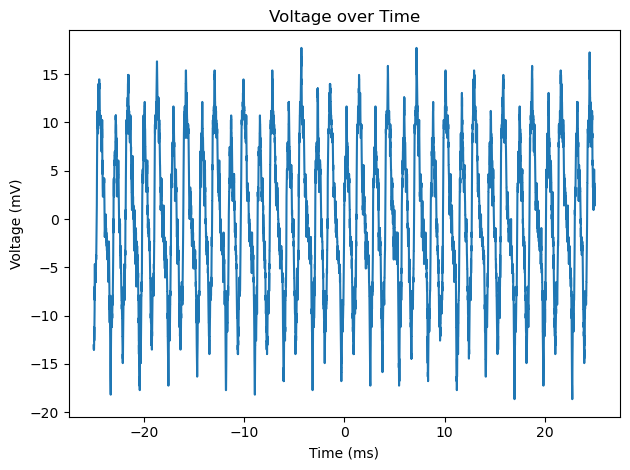

M: 10004


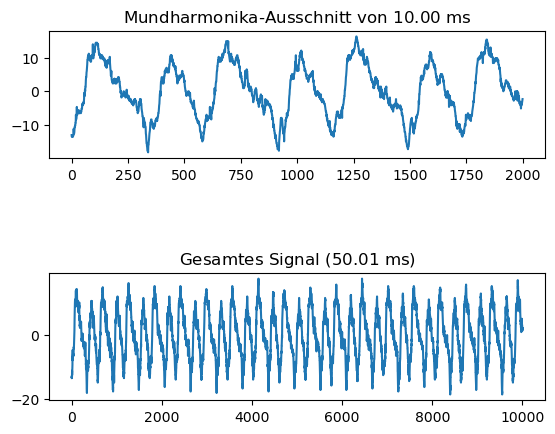

NameError: name 'signal' is not defined

In [4]:
df = pd.read_csv("Versuch3-1_harmonica/sound_harmonique-style.csv", delimiter=";", decimal=",", skiprows=[1])
plt.plot(df["Zeit"], df["Kanal A"])
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Voltage over Time")
plt.tight_layout()
plt.show()
v = df["Kanal A"]
N = len(v)

def dt(x): return df["Zeit"][x] - df["Zeit"][0]
def dts(x): return dt(x) / 1000 # Convert to time

print(f"M: {v.size}") # Anzahl Abtastpunkte
fig, axs = plt.subplots(2)
axs[0].plot(v[0:2000])
axs[0].set_title(f"Mundharmonika-Ausschnitt von ${dt(2000):.2f}$ ms")
axs[1].plot(v)
axs[1].set_title(f"Gesamtes Signal (${dt(v.size - 1):.2f}$ ms)") # Signaldauer
plt.subplots_adjust(hspace=0.9)
plt.show()

zc = np.where((signal[:-1] < 0))

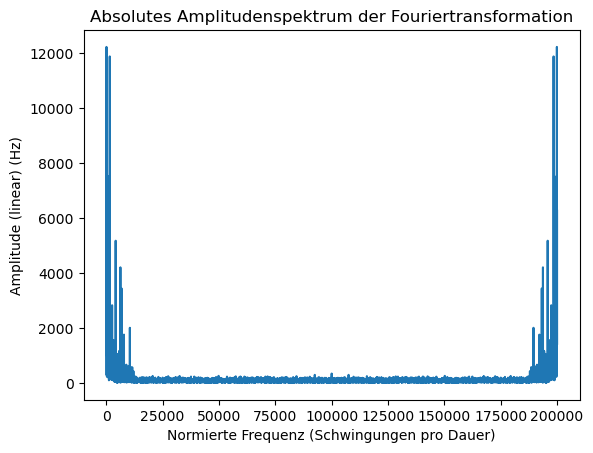

Wellenzahl: 621
Grundfrequenz: 12415.033986401637 Hz
Amplitude: 0.0001254656009371652
1039.6881197642115


In [37]:
fft = np.fft.fft(v)
fft_abs = np.abs(fft)
freqs = np.fft.fftfreq(M, dts)
k = np.arange(M)
k = k / T
idx = freqs > 0
freqs_pos = freqs[idx]
fft_pos = fft[idx]

A = 2.0 / (M * np.abs(fft_pos))

k0 = np.argmax(A)
f0 = k0 / (M * dt)
A0 = A[k0]

plt.plot(k,fft_abs)
plt.xlabel("Normierte Frequenz (Schwingungen pro Dauer)")
plt.ylabel("Amplitude (linear) (Hz)")
plt.title("Absolutes Amplitudenspektrum der Fouriertransformation")
plt.show()

print(f"Wellenzahl: {k0}\nGrundfrequenz: {f0} Hz\nAmplitude: {A0}")

print(k[np.argmax(fft[0:5000])])

## Aufgabe 3.2

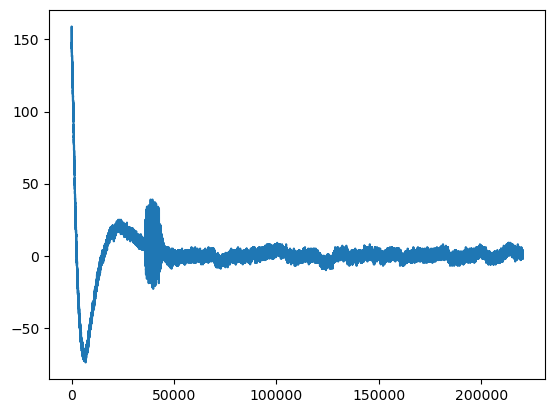

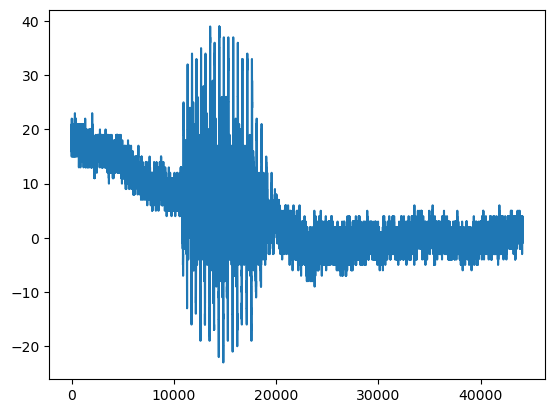

In [49]:
SAMPLE_FILE = "./versuch3-3/hoch_t1_0.npy"

audio = np.load(SAMPLE_FILE)
plt.plot(audio)
rate = 44100 # sampling rate per second
audio_trimmed = audio[25000 : 25000 + rate] # Sample trimmed down to a second
n = np.arange(rate) / rate

plt.show()
plt.plot(audio_trimmed)
plt.show()

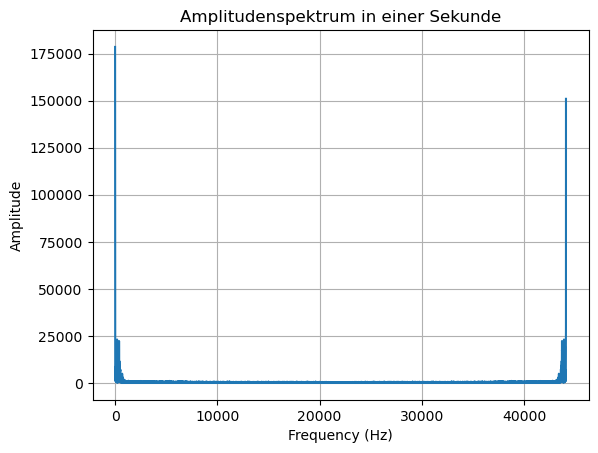

k0 0
Grundfrequenz: 0.0 Hz
Amplitude: 0.0001254656009371652


In [50]:
N = len(audio_trimmed)

ft = np.abs(np.fft.fft(audio_trimmed))
plt.plot(ft)


plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Amplitudenspektrum in einer Sekunde")
plt.grid(True)
plt.show()

k0 = np.argmax(A)
print("k0",k0)
f0 = freqs_pos[k0]
A9 = A[k0]

print(f"Grundfrequenz: {f0} Hz\nAmplitude: {A0}")

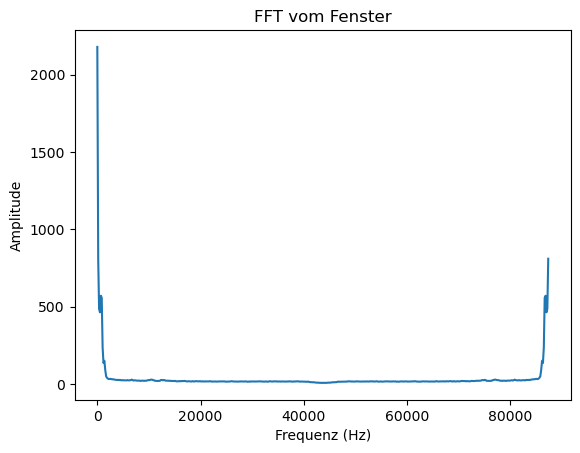

In [57]:
# d.
w_len = 512
std = w_len // 4 # Fenster entspricht 4 Standardabweichungen
overlap = w_len // 2

weight = windows.gaussian(w_len, std)

wins = []

ws = (rate // overlap) - 1
windowed = np.zeros((ws, w_len), dtype=float)
fftwin = np.zeros((ws, w_len), dtype=float)
midwin = np.zeros(w_len, dtype=float)

for i in range(ws):
    w_start = i * overlap
    windowed[i] = audio_trimmed[w_start : w_start + w_len] * weight
    fftwin[i] = np.abs(np.fft.fft(windowed[i])) ** 2
    midwin += fftwin[i]

midwin = np.sqrt(midwin / ws)

plt.plot(np.arange(w_len) * ws, midwin)
plt.ylabel("Amplitude")
plt.xlabel("Frequenz (Hz)")
plt.title("FFT vom Fenster")
plt.show()

In [ ]:
commands = ["hoch", "tief", "links", "rechts"]
speakers = ["t1", "t2"]

path = Path("./versuch3-3")
files = sorted(path.glob("*.npy"))

samples = {c: {sp: [] for sp in speakers + ["none"]} for c in commands}

for f in files:
    name = f.stem

    # Detect command
    cmd = next((c for c in commands if c in name), None)
    if cmd is None:
        continue

    # Detect speaker
    sp = next((s for s in speakers if s in name), "none")

    samples[cmd][sp].append(np.load(f))

def trim_to_1s(x):
    if len(x) < rate:
        out = np.zeros(rate)
        out[:len(x)] = x
        return out
    return x[:rate]

def averaged_power_spectrum(signal):
    spectra = []

    for start in range(0, len(signal) - w_len + 1, overlap):
        segment = signal[start:start+w_len] * weight
        FFT = np.fft.fft(segment)
        P = np.abs(FFT[:w_len//2])**2        # one-sided power
        spectra.append(P)

    return np.mean(spectra, axis=0)

processed = {
    cmd: {sp: [] for sp in ["none", "t1", "t2"]}
    for cmd in commands
}

for cmd in samples:
    for sp in samples[cmd]:
        for sig in samples[cmd][sp]:
            trimmed = trim_to_1s(sig)
            Pavg = averaged_power_spectrum(trimmed)
            processed[cmd][sp].append(Pavg)


reference = {}

for cmd in processed:
    all_spectra = []
    for sp in processed[cmd]:
        all_spectra.extend(processed[cmd][sp])
    reference[cmd] = np.mean(all_spectra, axis=0)

def corr(a, b):
    return np.corrcoef(a, b)[0, 1]

def classify(signal):
    trimmed = trim_to_1s(signal)
    Pavg = averaged_power_spectrum(trimmed)

    scores = {cmd: corr(Pavg, ref) for cmd, ref in reference.items()}
    best = max(scores, key=scores.get)
    return best, scores

def corr(a, b):
    return np.corrcoef(a, b)[0, 1]

def accuracy(testset):
    total = 0
    correct = 0
    mistakes = 0

    for cmd in testset:             # true command
        for sp in testset[cmd]:     # speaker group
            for sig in testset[cmd][sp]:  # each test signal
                pred, scores = classify(sig)
                total += 1
                if pred == cmd:
                    correct += 1
                else:
                    mistakes += 1

    return correct / total, correct, mistakes, total

acc, corr_num, mistakes, total = accuracy(processed)
print("Accuracy:", acc)
print("Correct:", corr_num)
print("Mistakes:", mistakes)
print("Total samples:", total)



Accuracy: 0.2
Correct: 12
Mistakes: 48
Total samples: 60
